In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
import random

import importlib
import model as md
import view as vw
from tqdm import tqdm

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Global_analytics\Monte_carlo\..


In [2]:
def monte_carlo_phase(phase_method,num_iter=1000):
    results = []

    for i in tqdm(range(num_iter), desc=f"Метод {phase_method.__name__}", unit=" шага"):

        F=400e3
        gen_unstable=1

        # --- Случайные параметры ---
        T=1/F
        fs_mult = random.randrange(3, 100, 1)
        fs = F * fs_mult

        duration_T=random.randrange(3, 100, 1)
        duration = duration_T * T
        
        phase_real=random.randrange(1, 180, 1)
        bits=random.randrange(5, 35, 1)
        SNR = random.randrange(30, 100, 1)

        # --- Генерация сигналов ---
        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)
        
        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))

        # --- Сохраняем результаты ---
        results.append({
            "FsM": fs_mult,
            "DT": duration_T,
            "SNR": SNR,
            "Bit": bits,
            "phase_real": phase_real,
            "phase_error_deg": err_deg
        })

    return pd.DataFrame(results)

In [ ]:
Y=[]
for i in range(0,len(phase_methods),1):
    Y.append(monte_carlo_phase(phase_methods[i], 20000))


Метод get_phase_SWFR: 100%|██████████| 20000/20000 [00:25<00:00, 784.14 шага/s] 


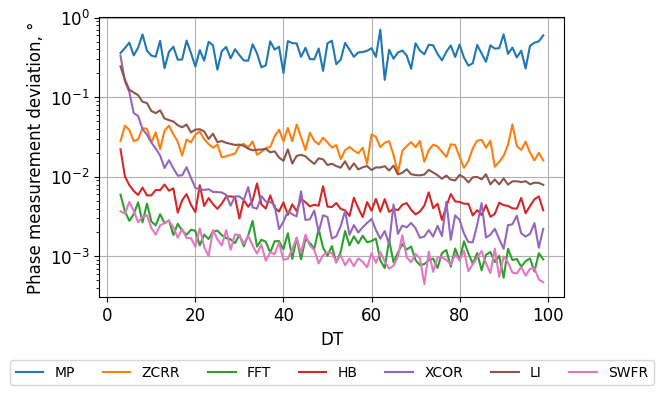

In [4]:
def clean_name(func):
    return func.__name__.replace("get_phase_", "").replace("get_phase", "")

method_names = [clean_name(m) for m in phase_methods]

fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(2, 1)
front = 12
ax1 = fig.add_subplot(gs[0, 0])

param="DT"

median_errors=[]
for i in range(len(Y)):
    median_error = Y[i].groupby(param)["phase_error_deg"].median() 
    ax1.plot(median_error.index,median_error, label=method_names[i])


ax1.set_xlabel(param, fontsize=front)
ax1.set_ylabel('Phase measurement deviation, °', fontsize=front)
ax1.tick_params(axis='both', labelsize=front)
ax1.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=len(method_names))
ax1.set_yscale('log')

In [ ]:
def plot_all_params(Y, params, method_names):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(len(params), 1, figsize=(7, 10), sharey=False)
    front = 12

    for j, param in enumerate(params):
        ax = axes[j]

        for i in range(len(Y)):
            median_error = Y[i].groupby(param)["phase_error_deg"].median()
            ax.plot(median_error.index, median_error, label=method_names[i])

        ax.set_xlabel(param, fontsize=front)
        ax.set_ylabel('Error, °', fontsize=front)
        ax.set_yscale('log')
        ax.grid(True)
        ax.tick_params(axis='both', labelsize=front)

    # одна общая легенда
    fig.legend(method_names, loc='upper center', ncol=len(method_names))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def plot_all_params_black(Y, params, method_names):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(
    len(params), 1, 
    figsize=(8, 12), 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1, 1]} # Первые два выше остальных
    )
    front = 12

    linestyles = ['-', '--', '-.', ':', (0, (3,1,1,1))]
    markers = ['o', 's', '^', 'd', 'x', 'p','*']

    for j, param in enumerate(params):
        ax = axes[j]

        for i in range(len(Y)):
            median_error = Y[i].groupby(param)["phase_error_deg"].median()

            marker_step = max(len(median_error) // 15, 1)   

            ax.plot(
                median_error.index,
                median_error,
                linestyle=linestyles[i % len(linestyles)],
                marker=markers[i % len(markers)],
                markersize=5,
                markevery=marker_step,
                color='black',
                markerfacecolor='white',
                markeredgecolor='black',
                linewidth=1.2,
                alpha=0.8,
                label=method_names[i]
            )

        # Убираем стандартные подписи
        ax.set_xlabel('')
        ax.set_ylabel('')

        

        # Подпись Y — СВЕРХУ оси
        ax.text(
            0.0, 1.02,
            'Error, °',
            transform=ax.transAxes,
            fontsize=front,
            ha='left',
            va='bottom'
        )

        # Подпись X — СПРАВА от оси
        ax.text(
            1.02, -0.08,
            param,
            transform=ax.transAxes,
            fontsize=front,
            ha='left',
            va='top'
        )

        ax.set_yscale('log')

        # ч/б сеткаax
        ax.grid(True, which='major', linestyle=':', linewidth=0.8, alpha=0.7)
        ax.grid(False, which='minor')

        ax.tick_params(axis='both', labelsize=front)

    #fig.tight_layout(rect=[0, 0.05, 1, 1])

    # общая легенда (тоже ч/б)
    fig.legend(
        method_names,
        loc='upper center',
        ncol=len(method_names),
        bbox_to_anchor=(0.5, 0.93),
        frameon=False
    )
    plt.subplots_adjust(hspace=0.3)

    #plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

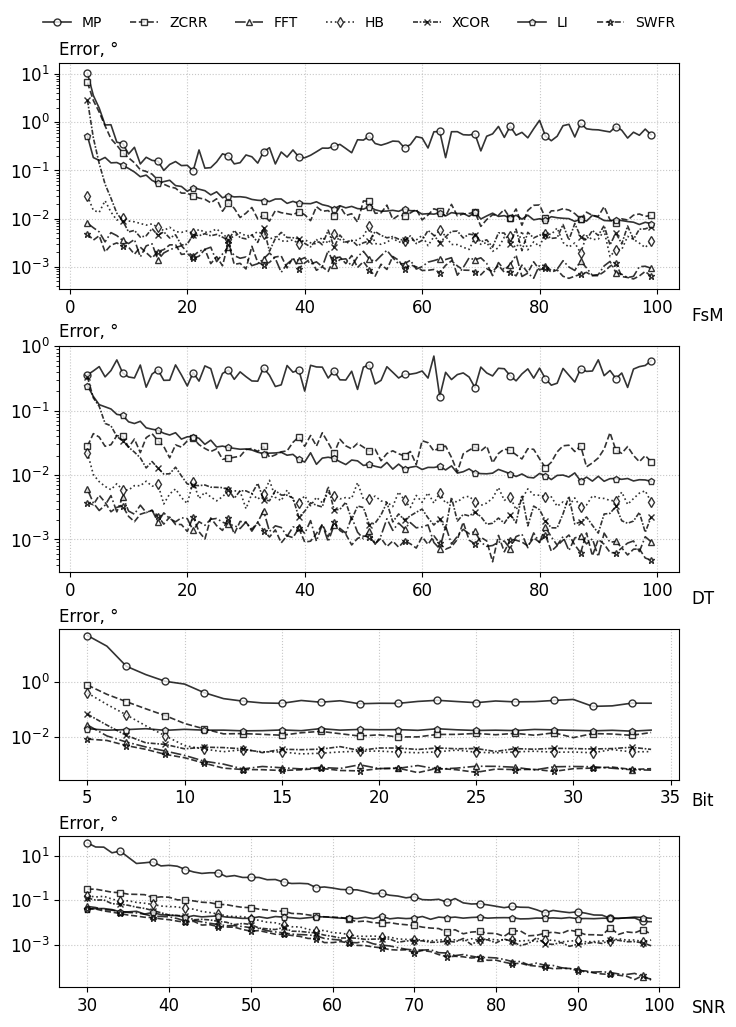

In [77]:
params = ["FsM", "DT", "Bit","SNR"]
method_names = [clean_name(m) for m in phase_methods]

plot_all_params_black(Y, params, method_names)

In [60]:
import numpy as np
from scipy.optimize import curve_fit


def falling_exp(x, a, b, c):
    return a * np.exp(-b * x) + c


def get_saturation_with_r2(x, y, r2_threshold=0.9):
    # 🔧 приведение типов
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # защита от мусора
    if len(x) < 3:
        return None, 0.0

    try:
        popt, _ = curve_fit(
            falling_exp,
            x,
            y,
            p0=[np.max(y), 0.1, np.min(y)],
            maxfev=10000
        )
    except:
        return None, 0.0

    y_fit = falling_exp(x, *popt)

    # R²
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    if ss_tot == 0:
        return None, 0.0

    r2 = 1 - ss_res / ss_tot

    if r2 < r2_threshold:
        return None, r2

    # saturation
    a, b, c = popt

    # защита от странных фиттов
    if b <= 0:
        return None, r2

    initial_slope = abs(a * b)
    delta = initial_slope * 0.01

    x_stop = -np.log(delta / (abs(a) * b)) / b

    return x_stop, r2

import pandas as pd

def build_table_r2(Y, params, method_names, r2_threshold=0.9):
    data = {}

    for param in params:
        values = []

        for i, df in enumerate(Y):
            median_error = df.groupby(param)["phase_error_deg"].median()

            x = median_error.index.values
            y = median_error.values

            x_stop, r2 = get_saturation_with_r2(x, y, r2_threshold)

            if x_stop is None:
                values.append(np.nan)
                print(f"{method_names[i]} | {param}: плохой фит (R²={r2:.3f})")
            else:
                values.append(round(float(x_stop), 2))
                print(f"{method_names[i]} | {param}: OK (R²={r2:.3f})")

        data[param] = values
    df_result = pd.DataFrame(data, index=method_names).T
    return df_result

def save_to_excel_pretty(df, filename="saturation_table.xlsx"):
    from openpyxl import load_workbook

    # сохраняем
    df.to_excel(filename)

    # открываем и форматируем
    wb = load_workbook(filename)
    ws = wb.active

    # автоширина колонок
    for col in ws.columns:
        max_length = 0
        col_letter = col[0].column_letter

        for cell in col:
            try:
                if cell.value:
                    max_length = max(max_length, len(str(cell.value)))
            except:
                pass

        ws.column_dimensions[col_letter].width = max_length + 2

    wb.save(filename)

    print(f"Excel файл сохранён в: {filename}")

In [61]:
params = ["FsM", "DT","Bit", "SNR"]
method_names = [clean_name(m) for m in phase_methods]

df_sat = build_table_r2(Y, params, method_names,0.7)

print("\nТаблица точек насыщения:")
print(df_sat)

save_to_excel_pretty(df_sat, "my_results.xlsx")

MP | FsM: OK (R²=0.955)
ZCRR | FsM: OK (R²=0.996)
FFT | FsM: OK (R²=0.843)
HB | FsM: OK (R²=0.837)
XCOR | FsM: OK (R²=0.999)
LI | FsM: OK (R²=0.867)
SWFR | FsM: OK (R²=0.748)
MP | DT: плохой фит (R²=0.007)
ZCRR | DT: плохой фит (R²=0.219)
FFT | DT: OK (R²=0.759)
HB | DT: OK (R²=0.720)
XCOR | DT: OK (R²=0.978)
LI | DT: OK (R²=0.950)
SWFR | DT: OK (R²=0.829)
MP | Bit: OK (R²=0.995)
ZCRR | Bit: OK (R²=0.999)
FFT | Bit: OK (R²=0.991)
HB | Bit: OK (R²=1.000)
XCOR | Bit: OK (R²=0.999)
LI | Bit: плохой фит (R²=0.134)
SWFR | Bit: OK (R²=0.979)
MP | SNR: OK (R²=0.978)
ZCRR | SNR: OK (R²=0.996)
FFT | SNR: OK (R²=0.997)
HB | SNR: OK (R²=0.991)
XCOR | SNR: OK (R²=0.993)
LI | SNR: OK (R²=0.936)
SWFR | SNR: OK (R²=0.996)

Таблица точек насыщения:
        MP   ZCRR    FFT     HB   XCOR     LI   SWFR
FsM   4.38   6.17  34.62  26.34   2.61  19.42  79.95
DT     NaN    NaN  68.35   5.03   8.83  30.14  72.95
Bit   4.52   6.26   5.82   4.84   4.51    NaN  12.52
SNR  17.03  46.16  40.24  38.84  28.11  30.81